Step 1 — Load Libraries

In [1]:
# %% Step 1 - Load libraries

# Check GPU name and GPU RAM in Google Colab
import subprocess  # Used to run nvidia-smi command

def check_gpu():  # Define function to check GPU details
    try:  # Try GPU check
        result = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total,memory.used,memory.free",
                "--format=csv,noheader,nounits"
            ],
            encoding="utf-8"
        )  # Run nvidia-smi command

        gpu_info = result.strip().split("\n")  # Split GPU output line by line

        for i, gpu in enumerate(gpu_info):  # Loop through GPUs
            name, total, used, free = gpu.split(",")  # Split GPU details

            total = int(total.strip())  # Convert total memory to int
            used = int(used.strip())  # Convert used memory to int
            free = int(free.strip())  # Convert free memory to int

            print(f"GPU {i + 1}")  # Print GPU number
            print(f"Name       : {name.strip()}")  # Print GPU name
            print(f"Total RAM  : {total} MB / {total / 1024:.2f} GB")  # Print total RAM
            print(f"Used RAM   : {used} MB / {used / 1024:.2f} GB")  # Print used RAM
            print(f"Free RAM   : {free} MB / {free / 1024:.2f} GB")  # Print free RAM
            print("-" * 40)  # Print separator

    except Exception as e:  # Catch error if GPU is not available
        print("No GPU detected or nvidia-smi is not available.")  # Print no GPU message
        print("Error:", e)  # Print error

check_gpu()  # Run GPU check

!pip install mne PyWavelets scikit-learn seaborn tensorflow pandas tqdm

import os  # Used for folder and file operations
import gc  # Used for memory cleanup
import numpy as np  # Used for numerical arrays
import mne  # Used for EEG processing
import pywt  # Used for wavelet processing
import random  # Used for random seed control

from sklearn.decomposition import FastICA  # Used for ICA
from sklearn.model_selection import train_test_split  # Used for train-validation split
from sklearn.metrics import (
    roc_curve, auc, classification_report, confusion_matrix,
    cohen_kappa_score
)  # Used for model evaluation

from collections import defaultdict  # Used for subject/class counting
from typing import Optional, Union, Sequence, Dict, Tuple, List, Any  # Used for type hints

import matplotlib.pyplot as plt  # Used for plotting
import seaborn as sns  # Used for confusion matrix heatmap
import pandas as pd  # Used for saving saliency scores
from tqdm import tqdm  # Used for progress bars

import tensorflow as tf  # Used for deep learning
from tensorflow.keras import backend as K  # Used for Keras backend functions
from tensorflow.keras.models import Sequential, Model  # Used for model creation
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    Lambda, Input, DepthwiseConv2D, Activation, AveragePooling2D,
    SeparableConv2D, Add, GlobalAveragePooling2D, GlobalAveragePooling1D,
    MultiHeadAttention, Reshape, LayerNormalization, Multiply
)  # Used for EEGFormer model layers
from tensorflow.keras.optimizers import Adam  # Used as optimizer
from tensorflow.keras.losses import SparseCategoricalCrossentropy  # Imported from original code
from tensorflow.keras.metrics import SparseCategoricalAccuracy  # Imported from original code
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)  # Used for training callbacks

try:  # Try enabling TensorFlow interactive logging
    tf.keras.utils.enable_interactive_logging()
except Exception:  # Ignore if not supported
    pass

'''
# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
'''

print("[STEP 1] Libraries loaded successfully.")  # Print completion message
print("[STEP 1] TensorFlow version:", tf.__version__)  # Print TensorFlow version

GPU 1
Name       : NVIDIA A100-SXM4-40GB
Total RAM  : 40960 MB / 40.00 GB
Used RAM   : 0 MB / 0.00 GB
Free RAM   : 40442 MB / 39.49 GB
----------------------------------------
[STEP 1] Libraries loaded successfully.
[STEP 1] TensorFlow version: 2.20.0


Step 2 — Helper to Load EEG Data Locally

In [2]:
# %% Step 2 - Function to load local EEG data with labels

def load_eeg_data_with_target(
    folder_path: str,  # Path to session folder
    session_name: str,  # Session name: ses-1 or ses-2
    max_samples: int = 118000,  # Maximum samples to keep
    discard_samples: int = 10000  # Samples to discard from beginning
):
    """
    Load EEG data from all .set files in a local folder and assign labels based on session.
    Returns:
        data_list: list of EEG arrays, each shape (channels, samples)
        targets: list of labels
        sfreq_list: list of sampling frequencies
    """

    print(f"\n[STEP 2] Checking folder: {folder_path}")  # Print folder being checked

    if not os.path.isdir(folder_path):  # Check whether folder exists
        print(f"[STEP 2] Folder not found, skipping: {folder_path}")  # Print missing folder
        return [], [], []  # Return empty lists

    eeg_files = [f for f in os.listdir(folder_path) if f.endswith(".set")]  # Find .set files

    print(f"[STEP 2] Found {len(eeg_files)} .set file(s) in {folder_path}")  # Print file count

    data_list = []  # Store EEG data
    targets = []  # Store labels
    sfreq_list = []  # Store sampling rates

    for eeg_file in eeg_files:  # Loop through EEG files
        file_path = os.path.join(folder_path, eeg_file)  # Create full file path

        print(f"[STEP 2] Loading file: {file_path}")  # Print current file path

        try:  # Try loading EEG file
            raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)  # Load EEGLAB .set file

            data = raw.get_data().astype(np.float32)  # Get EEG data as float32
            sfreq = float(raw.info["sfreq"])  # Get sampling frequency

            print(f"[STEP 2] Original shape: {data.shape}, sfreq: {sfreq}")  # Print original shape and fs

            if data.shape[1] > max_samples:  # Check if signal is longer than max_samples
                data = data[:, :max_samples]  # Trim signal
                print(f"[STEP 2] Trimmed to first {max_samples} samples: {data.shape}")  # Print trimmed shape

            if data.shape[1] > discard_samples:  # Check if enough samples exist to discard
                data = data[:, discard_samples:]  # Discard first samples
                print(f"[STEP 2] Discarded first {discard_samples} samples: {data.shape}")  # Print final shape
            else:  # If not enough samples
                print(
                    f"[STEP 2] Warning: Not enough data to discard "
                    f"{discard_samples} samples in {eeg_file}, skipping."
                )  # Print warning
                continue  # Skip this file

            data_list.append(data)  # Add data to list
            sfreq_list.append(sfreq)  # Add sampling rate to list

            if session_name == "ses-1":  # Check session 1
                targets.append(0)  # Label session 1 as class 0
            elif session_name == "ses-2":  # Check session 2
                targets.append(1)  # Label session 2 as class 1
            else:  # Unknown session
                print(f"[STEP 2] Warning: Unknown session name: {session_name}")  # Print warning

        except FileNotFoundError as e:  # Catch missing .fdt file
            print(f"[STEP 2] Missing linked .fdt file for {eeg_file}")  # Print missing file message
            print(f"[STEP 2] Error: {e}")  # Print error

        except Exception as e:  # Catch other loading errors
            print(f"[STEP 2] Error loading {eeg_file}")  # Print loading error
            print(f"[STEP 2] Error type: {type(e).__name__}")  # Print error type
            print(f"[STEP 2] Error: {e}")  # Print error message

    print(
        f"[STEP 2] Completed folder {folder_path}. "
        f"Loaded {len(data_list)} valid EEG sample(s)."
    )  # Print folder summary

    return data_list, targets, sfreq_list  # Return loaded data, labels, and sampling rates

Step 3 — New Data Preprocessing Pipeline

In [3]:
# %% Step 3 - New preprocessing pipeline

import numpy as np  # Import NumPy
import mne  # Import MNE
import pywt  # Import PyWavelets
from sklearn.decomposition import FastICA  # Import FastICA
from typing import Optional, Tuple, Union, Sequence, Dict, Any, List  # Import type hints

print("[STEP 3] Loading new preprocessing pipeline...")  # Print start message


# ---------------------------- wICA ----------------------------

def wavelet_enhanced_ica(
    data: np.ndarray,          # EEG data with shape (n_channels, n_times)
    n_components: int = 10,    # Number of ICA components
    wavelet: str = "db4",      # Wavelet type
    level: int = 3,            # Wavelet decomposition level
    random_state: int = 42,    # Random seed
) -> np.ndarray:
    """
    Wavelet-enhanced ICA (wICA): DWT along time → ICA on the
    low-frequency approximation → inverse DWT.
    """

    n_ch, n_t = data.shape  # Get channel count and time length
    n_components = min(n_components, n_ch)  # Cap ICA components to channel count

    coeffs = pywt.wavedec(data, wavelet=wavelet, level=level, axis=1)  # Apply wavelet decomposition
    A = coeffs[0]  # Select low-frequency approximation

    ica = FastICA(n_components=n_components, random_state=random_state)  # Create FastICA object
    S = ica.fit_transform(A.T).T  # Fit ICA and transform low-frequency approximation
    A_denoised = ica.inverse_transform(S.T).T  # Reconstruct denoised approximation

    coeffs[0] = A_denoised  # Replace approximation coefficients
    cleaned = pywt.waverec(coeffs, wavelet=wavelet, axis=1)  # Reconstruct cleaned signal

    if cleaned.shape[1] != n_t:  # Check reconstructed length
        if cleaned.shape[1] > n_t:  # If longer than original
            cleaned = cleaned[:, :n_t]  # Trim to original length
        else:  # If shorter than original
            cleaned = np.pad(cleaned, ((0, 0), (0, n_t - cleaned.shape[1])), mode="constant")  # Pad to original length

    return cleaned  # Return cleaned data


# --------------------- Helper: channel names ---------------------

def _names_from_index_mapping(
    n_channels: int,  # Number of channels
    index_to_name: Optional[Dict[int, str]]  # Optional channel mapping
) -> List[str]:
    """
    Build channel name list for 1..n_channels using a 1-based index→name mapping.
    If mapping is None or incomplete, fall back to 'EEG1'..'EEGn' for missing ones.
    Accepts 0-based mappings too.
    """

    names = []  # Create empty name list

    if index_to_name is None:  # If no mapping is given
        return [f"EEG{i+1}" for i in range(n_channels)]  # Return generic names

    keys = list(index_to_name.keys())  # Get mapping keys
    is_zero_based = (0 in keys) and (1 not in keys)  # Detect 0-based mapping

    for i in range(n_channels):  # Loop through channels
        key = i if is_zero_based else (i + 1)  # Select index key
        names.append(index_to_name.get(key, f"EEG{i+1}"))  # Add mapped or generic name

    return names  # Return channel names


# ------------------------- Main: preprocess -------------------------

def preprocess_eeg(
    eeg: np.ndarray,  # EEG array with shape (n_channels, n_times)
    sfreq: float,  # Original sampling rate
    *,
    index_to_name: Optional[Dict[int, str]] = None,  # Optional channel mapping
    use_standard_1010: bool = True,  # Whether to attach standard_1010 montage
    resample_to: Optional[float] = 250.0,  # Resampling target
    notch_freqs: Union[None, float, Sequence[float]] = 60.0,  # Notch frequency
    highpass: Optional[float] = 0.05,  # High-pass cutoff
    bad_point_z: float = 6.0,  # Bad point z threshold
    bad_channel_z: float = 5.0,  # Bad channel z threshold
    interpolate_bad_channels: bool = True,  # Whether to interpolate bad channels
    car: bool = True,  # Whether to apply common average reference
    use_wica: bool = True,  # Whether to apply wICA
    wica_components: int = 10,  # Number of wICA components
    wica_wavelet: str = "db4",  # wICA wavelet
    wica_level: int = 3,  # wICA level
    wica_random_state: int = 42,  # wICA random seed
    return_raw: bool = False,  # Whether to return MNE Raw object
) -> Union[Tuple[np.ndarray, float], Tuple[np.ndarray, float, mne.io.Raw]]:
    """
    Preprocess raw EEG with optional index→name mapping, standard_1010 montage,
    resampling, filtering, outlier repair, bad-channel interpolation, CAR, and wICA.
    """

    eeg = np.asarray(eeg, dtype=np.float32)  # Convert input to float32
    assert eeg.ndim == 2, "eeg must be 2D: (n_channels, n_times)"  # Validate shape

    n_channels, _ = eeg.shape  # Get number of channels
    ch_names = _names_from_index_mapping(n_channels, index_to_name)  # Build channel names

    ch_types = ['eog' if str(n).upper().startswith("EOG") else 'eeg' for n in ch_names]  # Detect EOG channels

    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)  # Create MNE info
    raw = mne.io.RawArray(eeg, info, verbose=False)  # Create Raw object

    montage_applied = False  # Track montage status

    if use_standard_1010:  # Check montage flag
        try:  # Try applying montage
            mont = mne.channels.make_standard_montage("standard_1010")  # Create standard_1010 montage
            raw.set_montage(mont, match_case=False, on_missing="ignore")  # Attach montage
            montage_applied = True  # Mark montage as applied
        except Exception:  # If montage fails
            montage_applied = False  # Continue without montage

    if resample_to is not None and float(resample_to) != float(sfreq):  # Check resampling
        raw.resample(sfreq=resample_to, npad="auto")  # Resample data

    sfreq_out = float(raw.info["sfreq"])  # Store output sampling rate

    if notch_freqs is not None:  # Check notch filter
        raw.notch_filter(freqs=notch_freqs, verbose=False)  # Apply notch filter

    if highpass is not None:  # Check high-pass filter
        raw.filter(l_freq=highpass, h_freq=None, verbose=False)  # Apply high-pass filter

    X = raw.get_data()  # Get current EEG data
    mu = np.mean(X, axis=1, keepdims=True)  # Calculate channel mean
    sd = np.std(X, axis=1, keepdims=True) + 1e-12  # Calculate channel standard deviation
    hi = mu + bad_point_z * sd  # Calculate upper threshold
    lo = mu - bad_point_z * sd  # Calculate lower threshold
    bad_idx = (X > hi) | (X < lo)  # Detect bad points

    if np.any(bad_idx):  # Check bad points exist
        X_fixed = X.copy()  # Copy data
        t = np.arange(X.shape[1], dtype=float)  # Create time index

        for ch in range(n_channels):  # Loop through channels
            mask = bad_idx[ch]  # Get bad mask

            if mask.any():  # Check channel has bad points
                good = ~mask  # Get good points

                if good.sum() >= 2:  # Need at least 2 good points
                    X_fixed[ch, mask] = np.interp(t[mask], t[good], X_fixed[ch, good])  # Interpolate bad points

        raw._data = X_fixed  # Replace Raw data

    if interpolate_bad_channels and montage_applied:  # Check bad channel interpolation
        X = raw.get_data(picks="eeg")  # Get EEG channels only

        if X.size > 0:  # Check EEG data exists
            ch_std = X.std(axis=1)  # Calculate channel std
            med = np.median(ch_std)  # Calculate median std
            mad = np.median(np.abs(ch_std - med)) + 1e-12  # Calculate MAD
            z = 0.6745 * (ch_std - med) / mad  # Calculate robust z-score
            eeg_names = mne.pick_info(raw.info, mne.pick_types(raw.info, eeg=True)).ch_names  # Get EEG names
            bads = [eeg_names[i] for i in np.where(np.abs(z) > bad_channel_z)[0]]  # Detect bad channels
            raw.info["bads"] = bads  # Mark bad channels

            if bads:  # Check bad channels exist
                raw.interpolate_bads(reset_bads=True, verbose=False)  # Interpolate bad channels

    if car:  # Check CAR flag
        raw.set_eeg_reference("average", projection=True)  # Set average reference
        raw.apply_proj()  # Apply reference

    if use_wica:  # Check wICA flag
        cleaned = wavelet_enhanced_ica(
            raw.get_data(),
            n_components=wica_components,
            wavelet=wica_wavelet,
            level=wica_level,
            random_state=wica_random_state
        )  # Apply wICA

        raw = mne.io.RawArray(cleaned, raw.info, verbose=False)  # Rebuild Raw object

    cleaned = raw.get_data()  # Get final cleaned data

    if return_raw:  # Check return raw flag
        return cleaned, sfreq_out, raw  # Return cleaned data, fs, and Raw

    return cleaned, sfreq_out  # Return cleaned data and output fs


# Quick reference channel map
BCI2A_INDEX_TO_NAME: Dict[int, str] = {
    1:"Fz", 2:"FC3", 3:"FC1", 4:"FCz", 5:"FC2", 6:"FC4",
    7:"C5", 8:"C3", 9:"C1", 10:"Cz", 11:"C2", 12:"C4", 13:"C6",
    14:"CP3", 15:"CP1", 16:"CPz", 17:"CP2", 18:"CP4",
    19:"P1", 20:"Pz", 21:"P2", 22:"POz",
    23:"EOG-left", 24:"EOG-central", 25:"EOG-right"
}  # BCI IV-2a channel map

print("[STEP 3] New preprocessing pipeline loaded successfully.")  # Print completion

[STEP 3] Loading new preprocessing pipeline...
[STEP 3] New preprocessing pipeline loaded successfully.


Step 4.1 — One-Time Extract ZIP to Google Drive

In [4]:
'''# %% Step 4.1 - ONE-TIME: Extract New Dataset.zip to Google Drive permanently

import os  # Import OS module
import zipfile  # Import ZIP handling module
from google.colab import drive  # Import Google Drive mount function

print("[STEP 4.1] Mounting Google Drive...")  # Print mount status
drive.mount("/content/drive")  # Mount Google Drive

zip_path = "/content/drive/MyDrive/New Dataset.zip"  # Set ZIP file path

drive_extract_root = "/content/drive/MyDrive/eeg_dataset_extracted"  # Set extraction root

print("[STEP 4.1] ZIP path:")  # Print label
print(zip_path)  # Print ZIP path

print("[STEP 4.1] Drive extract root:")  # Print label
print(drive_extract_root)  # Print extract root

if not os.path.isfile(zip_path):  # Check ZIP exists
    raise RuntimeError(
        f"[STEP 4.1] ZIP file not found: {zip_path}\n"
        "Please check whether 'New Dataset.zip' is inside MyDrive."
    )  # Raise error if ZIP missing

os.makedirs(drive_extract_root, exist_ok=True)  # Create extraction root if missing

expected_dataset_path = os.path.join(drive_extract_root, "New Dataset")  # Expected extracted path

if os.path.isdir(expected_dataset_path):  # Check already extracted
    print("[STEP 4.1] Dataset already appears to be extracted.")  # Print status
    print("[STEP 4.1] Existing path:")  # Print label
    print(expected_dataset_path)  # Print existing path
    print("[STEP 4.1] First few items:")  # Print label
    print(os.listdir(expected_dataset_path)[:20])  # Print first few items
    print("[STEP 4.1] No need to extract again.")  # Print no extraction needed
else:  # If not extracted
    print("[STEP 4.1] Extracting ZIP into Google Drive...")  # Print extraction start
    print("[STEP 4.1] This may take some time because it writes to Drive.")  # Print note

    with zipfile.ZipFile(zip_path, "r") as zip_ref:  # Open ZIP
        zip_ref.extractall(drive_extract_root)  # Extract ZIP

    print("[STEP 4.1] Extraction completed.")  # Print extraction done

    if not os.path.isdir(expected_dataset_path):  # Check expected folder exists
        print("[STEP 4.1] Expected folder not found directly.")  # Print warning
        print("[STEP 4.1] Contents of drive_extract_root:")  # Print label
        print(os.listdir(drive_extract_root))  # Print contents

        raise RuntimeError(
            "[STEP 4.1] Extraction completed, but expected 'New Dataset' folder was not found. "
            "Check the extracted folder structure."
        )  # Raise structure error

    print("[STEP 4.1] Extracted dataset path:")  # Print label
    print(expected_dataset_path)  # Print dataset path

    print("[STEP 4.1] First few items:")  # Print label
    print(os.listdir(expected_dataset_path)[:20])  # Print first few files/folders

print("[STEP 4.1] Completed successfully.")  # Print completion'''

'# %% Step 4.1 - ONE-TIME: Extract New Dataset.zip to Google Drive permanently\n\nimport os  # Import OS module\nimport zipfile  # Import ZIP handling module\nfrom google.colab import drive  # Import Google Drive mount function\n\nprint("[STEP 4.1] Mounting Google Drive...")  # Print mount status\ndrive.mount("/content/drive")  # Mount Google Drive\n\nzip_path = "/content/drive/MyDrive/New Dataset.zip"  # Set ZIP file path\n\ndrive_extract_root = "/content/drive/MyDrive/eeg_dataset_extracted"  # Set extraction root\n\nprint("[STEP 4.1] ZIP path:")  # Print label\nprint(zip_path)  # Print ZIP path\n\nprint("[STEP 4.1] Drive extract root:")  # Print label\nprint(drive_extract_root)  # Print extract root\n\nif not os.path.isfile(zip_path):  # Check ZIP exists\n    raise RuntimeError(\n        f"[STEP 4.1] ZIP file not found: {zip_path}\n"\n        "Please check whether \'New Dataset.zip\' is inside MyDrive."\n    )  # Raise error if ZIP missing\n\nos.makedirs(drive_extract_root, exist_ok=

Step 4.2 — Copy Extracted Folder from Drive to /content

In [5]:
# %% Step 4.2 - Copy permanently extracted Drive dataset to fast Colab local disk

import os  # Import OS module
import shutil  # Import shutil for copying/removing folders
from google.colab import drive  # Import Google Drive mount function

print("[STEP 4.2] Mounting Google Drive...")  # Print mount status
drive.mount("/content/drive")  # Mount Google Drive

print("[STEP 4.2] Google Drive mounted.")  # Print mounted message

drive_dataset_path = "/content/drive/MyDrive/eeg_dataset_extracted/New Dataset"  # Source dataset path

print("[STEP 4.2] Drive dataset path:")  # Print label
print(drive_dataset_path)  # Print source path

if not os.path.isdir(drive_dataset_path):  # Check source exists
    raise RuntimeError(
        f"[STEP 4.2] Drive dataset path not found: {drive_dataset_path}\n"
        "Please run Step 4.1 first."
    )  # Raise error if source missing

local_root = "/content/eeg_dataset"  # Local root path
base_path = "/content/eeg_dataset/New Dataset"  # Local dataset path

print("[STEP 4.2] Local destination base_path:")  # Print label
print(base_path)  # Print local destination path

FORCE_COPY_FROM_DRIVE = True  # Set True to copy fresh version every time

if FORCE_COPY_FROM_DRIVE and os.path.isdir(local_root):  # Check whether old local folder exists
    print(f"[STEP 4.2] Removing old local folder: {local_root}")  # Print removing message
    shutil.rmtree(local_root)  # Remove old local folder

os.makedirs(local_root, exist_ok=True)  # Create local root

print("[STEP 4.2] Copying dataset from Drive to Colab local disk...")  # Print copy start
print("[STEP 4.2] This may take some time, but training/loading will be faster after this.")  # Print note

shutil.copytree(
    drive_dataset_path,
    base_path,
    dirs_exist_ok=True
)  # Copy dataset to local disk

print("[STEP 4.2] Copy completed.")  # Print copy completion

if not os.path.isdir(base_path):  # Check local dataset exists
    raise RuntimeError(f"[STEP 4.2] Local base_path not found after copy: {base_path}")  # Raise error

print("[STEP 4.2] Local base_path exists.")  # Print path exists
print("[STEP 4.2] First few items in base_path:")  # Print label
print(os.listdir(base_path)[:20])  # Print first few items

if "sub-01" not in os.listdir(base_path):  # Check expected subject folder
    print("[STEP 4.2] Warning: sub-01 not found directly inside base_path.")  # Print warning
    print("[STEP 4.2] You may need to check folder nesting.")  # Print folder nesting note

print("[STEP 4.2] Completed successfully.")  # Print completion

[STEP 4.2] Mounting Google Drive...
Mounted at /content/drive
[STEP 4.2] Google Drive mounted.
[STEP 4.2] Drive dataset path:
/content/drive/MyDrive/eeg_dataset_extracted/New Dataset
[STEP 4.2] Local destination base_path:
/content/eeg_dataset/New Dataset
[STEP 4.2] Copying dataset from Drive to Colab local disk...
[STEP 4.2] This may take some time, but training/loading will be faster after this.
[STEP 4.2] Copy completed.
[STEP 4.2] Local base_path exists.
[STEP 4.2] First few items in base_path:
['sub-14', 'sub-21', 'sub-63', 'sub-43', 'sub-23', 'sub-51', 'sub-56', 'sub-54', 'sub-35', 'sub-55', 'sub-47', 'sub-64', 'sub-25', 'sub-18', 'sub-26', 'sub-42', 'sub-39', 'sub-71', 'sub-59', 'sub-04']
[STEP 4.2] Completed successfully.


Step 4.3 — Segment First, Then Preprocess Each Segment Separately

In [6]:
# ============================================================
# Suppress MNE logs and warnings
# Run this cell once before preprocessing
# ============================================================

import warnings
import logging
import mne

# Hide all MNE informational messages
mne.set_log_level("ERROR")

# Hide Python RuntimeWarnings (e.g., filter_length warnings)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Hide FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Hide UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

# Reduce logging from common libraries
logging.getLogger("mne").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

print("✓ MNE logs and warnings are suppressed.")

✓ MNE logs and warnings are suppressed.


In [7]:
# %% Step 4.3 - Segment first, preprocess each segment, with subject-level progress tracking

import os
import gc
import io
import contextlib
import numpy as np

from collections import defaultdict
from tqdm.auto import tqdm


# ============================================================
# 1. RAM tracking helper
# ============================================================

try:
    import psutil

    def print_ram(tag=""):
        """Print current Python process RAM usage."""

        process = psutil.Process(os.getpid())

        ram_gb = process.memory_info().rss / (1024 ** 3)

        total_gb = psutil.virtual_memory().total / (1024 ** 3)

        print(
            f"[RAM] {tag}: "
            f"used={ram_gb:.2f} GB / total={total_gb:.2f} GB"
        )

except Exception:

    def print_ram(tag=""):
        """Do nothing when psutil is unavailable."""

        pass


print("\n[STEP 4.3] Starting segment-first EEG preprocessing...")


# ============================================================
# 2. Dataset path
# ============================================================

base_path = "/content/eeg_dataset/New Dataset"

if not os.path.isdir(base_path):

    raise RuntimeError(
        f"[STEP 4.3] Dataset folder does not exist: {base_path}\n"
        "Please run Step 4.2 first."
    )

print(f"[STEP 4.3] Dataset path: {base_path}")

print_ram("initial")


# ============================================================
# 3. Basic EEGLAB file validation
# ============================================================

print("\n[STEP 4.3] Checking EEGLAB files...")

bad_files = []

set_file_count = 0

fdt_file_count = 0


for root, dirs, files in os.walk(base_path):

    set_files = [
        file_name
        for file_name in files
        if file_name.endswith(".set")
    ]

    fdt_files = [
        file_name
        for file_name in files
        if file_name.endswith(".fdt")
    ]

    set_file_count += len(set_files)

    fdt_file_count += len(fdt_files)


    for set_file in set_files:

        set_path = os.path.join(root, set_file)

        fdt_path = set_path.replace(".set", ".fdt")


        if os.path.getsize(set_path) == 0:

            bad_files.append(set_path)

            continue


        if os.path.exists(fdt_path):

            if os.path.getsize(fdt_path) == 0:

                bad_files.append(fdt_path)


print(
    f"[STEP 4.3] Found {set_file_count} .set files "
    f"and {fdt_file_count} .fdt files."
)


if bad_files:

    print("[STEP 4.3] Empty or corrupted files:")

    for bad_file in bad_files:

        print(" -", bad_file)


    raise RuntimeError(
        "[STEP 4.3] Some .set/.fdt files are empty or corrupted."
    )


print("[STEP 4.3] EEGLAB file check completed.")


# ============================================================
# 4. Subject configuration
# ============================================================

sub_folders = [
    f"sub-{subject_number:02d}"
    for subject_number in range(1, 72)
]

excluded_subjects = ["sub-69"]

training_subjects = [
    subject
    for subject in sub_folders
    if subject not in excluded_subjects
]

testing_subjects = excluded_subjects.copy()


print(
    f"\n[STEP 4.3] Training subjects: {len(training_subjects)}"
)

print(
    f"[STEP 4.3] Testing subjects: {testing_subjects}"
)


# ============================================================
# 5. Raw EEG segmentation function
# ============================================================

def segment_raw_eeg(
    data: np.ndarray,
    target: int,
    segment_size: int = 100
):
    """
    Divide raw EEG into non-overlapping segments before preprocessing.

    Input
    -----
    data:
        EEG array with shape (channels, time).

    target:
        Class label for the EEG trial.

    segment_size:
        Number of time samples in each segment.

    Returns
    -------
    raw_segments:
        List of arrays, each with shape (channels, segment_size).

    raw_targets:
        Corresponding segment labels.
    """

    raw_segments = []

    raw_targets = []


    if data.ndim == 3:

        data = data[0]


    if data.ndim != 2:

        raise ValueError(
            "Expected EEG shape (channels, time), "
            f"but received {data.shape}."
        )


    n_segments = data.shape[1] // segment_size


    for segment_index in range(n_segments):

        start = segment_index * segment_size

        end = start + segment_size

        segment = data[:, start:end]


        raw_segments.append(
            segment.astype(np.float32, copy=False)
        )

        raw_targets.append(int(target))


    return raw_segments, raw_targets


# ============================================================
# 6. Preprocess one EEG segment
# ============================================================

def preprocess_one_segment(segment: np.ndarray):
    """
    Apply the complete new preprocessing pipeline separately
    to one EEG segment.

    The sampling rate remains fixed at 500 Hz.
    """

    fs = 500.0


    cleaned_segment, fs_out = preprocess_eeg(

        eeg=segment.astype(
            np.float32,
            copy=False
        ),

        sfreq=fs,

        index_to_name=None,

        use_standard_1010=True,

        resample_to=None,

        notch_freqs=50.0,

        highpass=0.05,

        bad_point_z=6.0,

        bad_channel_z=5.0,

        interpolate_bad_channels=False,

        car=True,

        use_wica=True,

        wica_components=10,

        wica_wavelet="db4",

        wica_level=3,

        wica_random_state=42,

        return_raw=False
    )


    if not np.isclose(fs_out, fs):

        raise RuntimeError(
            f"Unexpected output sampling rate: "
            f"{fs_out} Hz instead of {fs} Hz."
        )


    return cleaned_segment.astype(
        np.float32,
        copy=False
    )


# ============================================================
# 7. Quiet folder loading
# ============================================================

def safe_load_folder(
    path,
    session,
    sub,
    split_name
):
    """
    Load one subject/session folder without printing all
    messages produced by load_eeg_data_with_target().
    """

    try:

        # Capture repeated print output from the existing loader.
        loader_output = io.StringIO()


        with contextlib.redirect_stdout(loader_output):

            data_list, targets, sfreq_list = (
                load_eeg_data_with_target(
                    folder_path=path,
                    session_name=session
                )
            )


        return data_list, targets, sfreq_list


    except Exception as error:

        print(
            f"\n[ERROR] Could not load "
            f"{split_name} {sub}/{session}: "
            f"{type(error).__name__}: {error}"
        )


        return [], [], []


# ============================================================
# 8. Main configuration and output containers
# ============================================================

max_per_class_per_subject = 200

segment_size = 100


selected_data = []

selected_targets = []

selected_subject_ids = []


selection_counts = defaultdict(
    lambda: {
        0: 0,
        1: 0
    }
)


total_train_trials_loaded = 0

total_train_segments_created = 0

total_train_segments_preprocessed = 0

total_train_segments_failed = 0


# ============================================================
# 9. Training subjects
# ============================================================

print(
    "\n[STEP 4.3] Processing training subjects..."
)


for subject_index, sub in enumerate(
    training_subjects,
    start=1
):

    print(
        f"\n[TRAIN] Subject {sub} "
        f"({subject_index}/{len(training_subjects)})"
    )


    subject_created = 0

    subject_processed = 0

    subject_failed = 0


    for session in ["ses-1", "ses-2"]:

        path = os.path.join(
            base_path,
            sub,
            session
        )


        if not os.path.isdir(path):

            print(
                f"[TRAIN] {sub}/{session}: folder missing."
            )

            continue


        data_list, targets, sfreq_list = safe_load_folder(

            path=path,

            session=session,

            sub=sub,

            split_name="TRAIN"
        )


        if len(data_list) == 0:

            print(
                f"[TRAIN] {sub}/{session}: no valid EEG trial."
            )

            continue


        for trial_index, (
            data,
            target,
            original_sfreq
        ) in enumerate(
            zip(
                data_list,
                targets,
                sfreq_list
            ),
            start=1
        ):

            total_train_trials_loaded += 1


            try:

                raw_segments, segment_targets = segment_raw_eeg(

                    data=data.astype(
                        np.float32,
                        copy=False
                    ),

                    target=int(target),

                    segment_size=segment_size
                )


                class_label = int(target)

                total_train_segments_created += len(
                    raw_segments
                )

                subject_created += len(raw_segments)


                remaining_segments = (
                    max_per_class_per_subject
                    - selection_counts[sub][class_label]
                )


                segments_to_process = min(

                    len(raw_segments),

                    max(remaining_segments, 0)
                )


                progress_description = (

                    f"{sub} | {session} | "
                    f"class {class_label}"
                )


                progress_bar = tqdm(

                    total=segments_to_process,

                    desc=progress_description,

                    unit="segment",

                    leave=False,

                    dynamic_ncols=True
                )


                for segment_index in range(
                    segments_to_process
                ):

                    segment = raw_segments[
                        segment_index
                    ]

                    segment_target = segment_targets[
                        segment_index
                    ]


                    try:

                        cleaned_segment = (
                            preprocess_one_segment(segment)
                        )


                        selected_data.append(
                            cleaned_segment
                        )

                        selected_targets.append(
                            int(segment_target)
                        )

                        selected_subject_ids.append(
                            sub
                        )


                        selection_counts[sub][
                            class_label
                        ] += 1


                        total_train_segments_preprocessed += 1

                        subject_processed += 1


                    except Exception as error:

                        total_train_segments_failed += 1

                        subject_failed += 1


                        tqdm.write(

                            f"[ERROR] {sub}/{session}, "
                            f"segment {segment_index + 1}: "
                            f"{type(error).__name__}: "
                            f"{error}"
                        )


                    finally:

                        progress_bar.update(1)


                progress_bar.close()


                del raw_segments

                del segment_targets


            except Exception as error:

                print(
                    f"[ERROR] Trial processing failed for "
                    f"{sub}/{session}: "
                    f"{type(error).__name__}: {error}"
                )


            finally:

                del data


        del data_list

        del targets

        del sfreq_list

        gc.collect()


    class_0_count = selection_counts[sub][0]

    class_1_count = selection_counts[sub][1]


    print(
        f"[TRAIN] Completed {sub} | "
        f"class 0: {class_0_count}/{max_per_class_per_subject} | "
        f"class 1: {class_1_count}/{max_per_class_per_subject} | "
        f"processed: {subject_processed} | "
        f"failed: {subject_failed}"
    )


    print_ram(f"after {sub}")


print(
    "\n[STEP 4.3] Training preprocessing completed."
)

print(
    "[STEP 4.3] Training trials loaded:",
    total_train_trials_loaded
)

print(
    "[STEP 4.3] Training raw segments created:",
    total_train_segments_created
)

print(
    "[STEP 4.3] Training segments preprocessed:",
    total_train_segments_preprocessed
)

print(
    "[STEP 4.3] Training segment failures:",
    total_train_segments_failed
)


# ============================================================
# 10. Test subjects
# ============================================================

print(
    "\n[STEP 4.3] Processing test subjects..."
)


test_data_augmented = []

test_targets_augmented = []

test_subject_ids_augmented = []


total_test_trials_loaded = 0

total_test_segments_created = 0

total_test_segments_preprocessed = 0

total_test_segments_failed = 0


for subject_index, sub in enumerate(
    testing_subjects,
    start=1
):

    print(
        f"\n[TEST] Subject {sub} "
        f"({subject_index}/{len(testing_subjects)})"
    )


    subject_created = 0

    subject_processed = 0

    subject_failed = 0


    for session in ["ses-1", "ses-2"]:

        path = os.path.join(
            base_path,
            sub,
            session
        )


        if not os.path.isdir(path):

            print(
                f"[TEST] {sub}/{session}: folder missing."
            )

            continue


        data_list, targets, sfreq_list = safe_load_folder(

            path=path,

            session=session,

            sub=sub,

            split_name="TEST"
        )


        if len(data_list) == 0:

            print(
                f"[TEST] {sub}/{session}: no valid EEG trial."
            )

            continue


        for trial_index, (
            data,
            target,
            original_sfreq
        ) in enumerate(
            zip(
                data_list,
                targets,
                sfreq_list
            ),
            start=1
        ):

            total_test_trials_loaded += 1


            try:

                raw_segments, segment_targets = segment_raw_eeg(

                    data=data.astype(
                        np.float32,
                        copy=False
                    ),

                    target=int(target),

                    segment_size=segment_size
                )


                total_test_segments_created += len(
                    raw_segments
                )

                subject_created += len(raw_segments)


                progress_description = (

                    f"{sub} | {session} | "
                    f"class {int(target)}"
                )


                progress_bar = tqdm(

                    total=len(raw_segments),

                    desc=progress_description,

                    unit="segment",

                    leave=False,

                    dynamic_ncols=True
                )


                for segment_index, (
                    segment,
                    segment_target
                ) in enumerate(
                    zip(
                        raw_segments,
                        segment_targets
                    ),
                    start=1
                ):

                    try:

                        cleaned_segment = (
                            preprocess_one_segment(segment)
                        )


                        test_data_augmented.append(
                            cleaned_segment
                        )

                        test_targets_augmented.append(
                            int(segment_target)
                        )

                        test_subject_ids_augmented.append(
                            sub
                        )


                        total_test_segments_preprocessed += 1

                        subject_processed += 1


                    except Exception as error:

                        total_test_segments_failed += 1

                        subject_failed += 1


                        tqdm.write(

                            f"[ERROR] {sub}/{session}, "
                            f"segment {segment_index}: "
                            f"{type(error).__name__}: "
                            f"{error}"
                        )


                    finally:

                        progress_bar.update(1)


                progress_bar.close()


                del raw_segments

                del segment_targets


            except Exception as error:

                print(
                    f"[ERROR] Trial processing failed for "
                    f"{sub}/{session}: "
                    f"{type(error).__name__}: {error}"
                )


            finally:

                del data


        del data_list

        del targets

        del sfreq_list

        gc.collect()


    print(
        f"[TEST] Completed {sub} | "
        f"created: {subject_created} | "
        f"processed: {subject_processed} | "
        f"failed: {subject_failed}"
    )


    print_ram(f"after {sub}")


print(
    "\n[STEP 4.3] Test preprocessing completed."
)

print(
    "[STEP 4.3] Test trials loaded:",
    total_test_trials_loaded
)

print(
    "[STEP 4.3] Test raw segments created:",
    total_test_segments_created
)

print(
    "[STEP 4.3] Test segments preprocessed:",
    total_test_segments_preprocessed
)

print(
    "[STEP 4.3] Test segment failures:",
    total_test_segments_failed
)


# ============================================================
# 11. Convert final lists into NumPy arrays
# ============================================================

print(
    "\n[STEP 4.3] Converting final results "
    "to NumPy arrays..."
)


selected_data = np.asarray(
    selected_data,
    dtype=np.float32
)

selected_targets = np.asarray(
    selected_targets,
    dtype=np.int32
)

selected_subject_ids = np.asarray(
    selected_subject_ids
)


test_data_augmented = np.asarray(
    test_data_augmented,
    dtype=np.float32
)

test_targets_augmented = np.asarray(
    test_targets_augmented,
    dtype=np.int32
)

test_subject_ids_augmented = np.asarray(
    test_subject_ids_augmented
)


gc.collect()


# ============================================================
# 12. Final summary
# ============================================================

print("\n[STEP 4.3] Final outputs:")

print(
    "[STEP 4.3] selected_data:",
    selected_data.shape
)

print(
    "[STEP 4.3] selected_targets:",
    selected_targets.shape
)

print(
    "[STEP 4.3] test_data_augmented:",
    test_data_augmented.shape
)

print(
    "[STEP 4.3] test_targets_augmented:",
    test_targets_augmented.shape
)


print("\n[STEP 4.3] Training class distribution:")

train_classes, train_counts = np.unique(
    selected_targets,
    return_counts=True
)

for class_label, count in zip(
    train_classes,
    train_counts
):

    print(
        f"Class {class_label}: {count}"
    )


print("\n[STEP 4.3] Test class distribution:")

test_classes, test_counts = np.unique(
    test_targets_augmented,
    return_counts=True
)

for class_label, count in zip(
    test_classes,
    test_counts
):

    print(
        f"Class {class_label}: {count}"
    )


print_ram("final")


print("\n[STEP 4.3] Completed successfully.")

print(
    "[STEP 4.3] Continue directly to Step 8."
)


[STEP 4.3] Starting segment-first EEG preprocessing...
[STEP 4.3] Dataset path: /content/eeg_dataset/New Dataset
[RAM] initial: used=0.91 GB / total=83.47 GB

[STEP 4.3] Checking EEGLAB files...
[STEP 4.3] Found 142 .set files and 142 .fdt files.
[STEP 4.3] EEGLAB file check completed.

[STEP 4.3] Training subjects: 70
[STEP 4.3] Testing subjects: ['sub-69']

[STEP 4.3] Processing training subjects...

[TRAIN] Subject sub-01 (1/70)


sub-01 | ses-1 | class 0:   0%|          | 0/200 [00:00<?, ?segment/s]

sub-01 | ses-2 | class 1:   0%|          | 0/200 [00:00<?, ?segment/s]

[TRAIN] Completed sub-01 | class 0: 200/200 | class 1: 200/200 | processed: 400 | failed: 0
[RAM] after sub-01: used=1.00 GB / total=83.47 GB

[TRAIN] Subject sub-02 (2/70)


sub-02 | ses-1 | class 0:   0%|          | 0/200 [00:00<?, ?segment/s]

...

sub-71 | ses-2 | class 1:   0%|          | 0/200 [00:00<?, ?segment/s]

[TRAIN] Completed sub-71 | class 0: 200/200 | class 1: 200/200 | processed: 400 | failed: 0
[RAM] after sub-71: used=1.64 GB / total=83.47 GB

[STEP 4.3] Training preprocessing completed.
[STEP 4.3] Training trials loaded: 140
[STEP 4.3] Training raw segments created: 151200
[STEP 4.3] Training segments preprocessed: 28000
[STEP 4.3] Training segment failures: 0

[STEP 4.3] Processing test subjects...

[TEST] Subject sub-69 (1/1)


sub-69 | ses-1 | class 0:   0%|          | 0/1080 [00:00<?, ?segment/s]

sub-69 | ses-2 | class 1:   0%|          | 0/1080 [00:00<?, ?segment/s]

[TEST] Completed sub-69 | created: 2160 | processed: 2160 | failed: 0
[RAM] after sub-69: used=1.70 GB / total=83.47 GB

[STEP 4.3] Test preprocessing completed.
[STEP 4.3] Test trials loaded: 2
[STEP 4.3] Test raw segments created: 2160
[STEP 4.3] Test segments preprocessed: 2160
[STEP 4.3] Test segment failures: 0

[STEP 4.3] Converting final results to NumPy arrays...

[STEP 4.3] Final outputs:
[STEP 4.3] selected_data: (28000, 61, 100)
[STEP 4.3] selected_targets: (28000,)
[STEP 4.3] test_data_augmented: (2160, 61, 100)
[STEP 4.3] test_targets_augmented: (2160,)

[STEP 4.3] Training class distribution:
Class 0: 14000
Class 1: 14000

[STEP 4.3] Test class distribution:
Class 0: 1080
Class 1: 1080
[RAM] final: used=2.39 GB / total=83.47 GB

[STEP 4.3] Completed successfully.
[STEP 4.3] Continue directly to Step 8.


Step 5 — Skip

In [8]:
# %% Step 5 - Skip

print("[STEP 5] Skipped.")  # Print skip status
print("[STEP 5] Reason: segmentation is already done inside Step 4.3 before preprocessing.")  # Print reason

[STEP 5] Skipped.
[STEP 5] Reason: segmentation is already done inside Step 4.3 before preprocessing.


Step 6 — Skip

In [9]:
# %% Step 6 - Skip

print("[STEP 6] Skipped.")  # Print skip status
print("[STEP 6] Reason: train/test segmentation is already completed in Step 4.3.")  # Print reason

[STEP 6] Skipped.
[STEP 6] Reason: train/test segmentation is already completed in Step 4.3.


Step 7 — Skip

In [10]:
# %% Step 7 - Skip

print("[STEP 7] Skipped.")  # Print skip status
print("[STEP 7] Reason: fair selection of 200 samples per class per subject is already done in Step 4.3.")  # Print reason

[STEP 7] Skipped.
[STEP 7] Reason: fair selection of 200 samples per class per subject is already done in Step 4.3.


Step 8 — Reshape for CNN

In [11]:
# %% Step 8 - Reshape data for CNN

train_data_cnn = selected_data[..., np.newaxis]  # Add CNN channel dimension to training data

test_data_cnn = test_data_augmented[..., np.newaxis]  # Add CNN channel dimension to test data

y_test_cnn = test_targets_augmented.astype(np.int32)  # Convert test labels to int32

print("\n[STEP 8] CNN reshaping completed.")  # Print completion
print(f"[STEP 8] Reshaped training data shape: {train_data_cnn.shape}")  # Print train shape
print(f"[STEP 8] Reshaped test data shape: {test_data_cnn.shape}")  # Print test shape
print(f"[STEP 8] Test labels shape: {y_test_cnn.shape}")  # Print test label shape


[STEP 8] CNN reshaping completed.
[STEP 8] Reshaped training data shape: (28000, 61, 100, 1)
[STEP 8] Reshaped test data shape: (2160, 61, 100, 1)
[STEP 8] Test labels shape: (2160,)


Step 9 — Normalization Using Training Statistics Only

In [12]:
# %% Step 9 - Data normalization using train statistics only

epsilon = 1e-6  # Small value to avoid division by zero

print("\n[STEP 9] Computing train mean and std...")  # Print start

train_mean = np.mean(
    train_data_cnn,
    axis=(0, 2, 3),
    keepdims=True
).astype(np.float32)  # Compute train mean only from training data

train_std = np.std(
    train_data_cnn,
    axis=(0, 2, 3),
    keepdims=True
).astype(np.float32)  # Compute train std only from training data

train_std = np.maximum(train_std, epsilon)  # Avoid zero std

print(f"[STEP 9] Train mean shape: {train_mean.shape}")  # Print mean shape
print(f"[STEP 9] Train std shape: {train_std.shape}")  # Print std shape

print("[STEP 9] Applying normalization...")  # Print applying status

train_data_norm = ((train_data_cnn - train_mean) / train_std).astype(np.float32)  # Normalize train data

test_data_norm = ((test_data_cnn - train_mean) / train_std).astype(np.float32)  # Normalize test data using train stats

print(f"[STEP 9] Normalized training data shape: {train_data_norm.shape}")  # Print normalized train shape
print(f"[STEP 9] Normalized test data shape: {test_data_norm.shape}")  # Print normalized test shape

unique_values, counts = np.unique(selected_targets, return_counts=True)  # Calculate training class distribution

print("\n[STEP 9] Final training class distribution:")  # Print class distribution
for value, count in zip(unique_values, counts):  # Loop class counts
    print(f"Value: {value}, Count: {count}")  # Print class count


[STEP 9] Computing train mean and std...
[STEP 9] Train mean shape: (1, 61, 1, 1)
[STEP 9] Train std shape: (1, 61, 1, 1)
[STEP 9] Applying normalization...
[STEP 9] Normalized training data shape: (28000, 61, 100, 1)
[STEP 9] Normalized test data shape: (2160, 61, 100, 1)

[STEP 9] Final training class distribution:
Value: 0, Count: 14000
Value: 1, Count: 14000


Step 10 — EEGFormer Modeling, Training, and Evaluation

[ENV] TensorFlow version: 2.20.0
[ENV] Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[ENV] GPU memory growth enabled.
[ENV] GPU TensorFlow test passed:
tf.Tensor(
[[ 7. 10.]
 [15. 22.]], shape=(2, 2), dtype=float32)

[STEP 10] Splitting train/validation data...
[STEP 10] Training data shape: (22400, 61, 100, 1)
[STEP 10] Validation data shape: (5600, 61, 100, 1)
[STEP 10] y_train shape: (22400,)
[STEP 10] y_val shape: (5600,)

[STEP 10] Checking required variables...
[STEP 10] Required variables are available.
[STEP 10] Model input shape: (61, 100, 1)
[STEP 10] Unique training labels: [0. 1.]

[STEP 10] Building EEGFormer model...


Model: "EEGNet_SpatialTransformer_refit"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 61, 100,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 61, 100,   │         37 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 61, 100,   │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 61, 100,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 61)        │      3,965 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 61, 1, 1)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 61, 100,   │          0 │ activation[0][0], │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 61, 100,   │      3,904 │ multiply[0][0]    │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 100,   │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 61, 100,   │         64 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 61, 100,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 100,   │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 61, 100,   │          0 │ activation_1[0][… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 100,   │        256 │ add[0][0]         │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 61, 12,    │          0 │ batch_normalizat… │
│ (AveragePooling2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 61, 12,    │          0 │ average_pooling2

 Total params: 190,755 (745.14 KB)

 Trainable params: 189,539 (740.39 KB)

...


Epoch 89: finished saving model to sub-69_eegformer_model.h5
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 1.7563e-04 - learning_rate: 2.5000e-04
Epoch 90/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9989 - loss: 0.0028
Epoch 90: val_loss did not improve from 0.00018
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9990 - loss: 0.0027 - val_accuracy: 0.9998 - val_loss: 7.1054e-04 - learning_rate: 2.5000e-04
Epoch 91/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9989 - loss: 0.0022
Epoch 91: val_loss improved from 0.00018 to 0.00005, saving model to sub-69_eegformer_model.h5



Epoch 91: finished saving model to sub-69_eegformer_model.h5
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9993 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 4.6665e-05 - learning_rate: 2.5000e-04
Epoch 92/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9994 - loss: 0.0018
Epoch 92: val_loss improved from 0.00005 to 0.00004, saving model to sub-69_eegformer_model.h5



Epoch 92: finished saving model to sub-69_eegformer_model.h5
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 4.1136e-05 - learning_rate: 2.5000e-04
Epoch 93/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9996 - loss: 0.0013
Epoch 93: val_loss did not improve from 0.00004
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9995 - loss: 0.0014 - val_accuracy: 0.9998 - val_loss: 1.8994e-04 - learning_rate: 2.5000e-04
Epoch 94/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9994 - loss: 0.0024
Epoch 94: val_loss did not improve from 0.00004
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9992 - loss: 0.0024 - val_accuracy: 0.9996 - val_loss: 4.5070e-04 - learning_rate: 2.5000e-04
Epoch 95/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9989 - loss: 0.0025
Epoch 95: val_loss did not improve from 0.00004
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9992 - loss: 0.0021 -


Epoch 100: finished saving model to sub-69_eegformer_model.h5
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 3.5110e-05 - learning_rate: 1.2500e-04
Epoch 101/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9998 - loss: 7.9093e-04
Epoch 101: val_loss did not improve from 0.00004
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 6.0416e-05 - learning_rate: 1.2500e-04
Epoch 102/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9999 - loss: 7.4595e-04
Epoch 102: val_loss did not improve from 0.00004
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 1.6750e-04 - learning_rate: 1.2500e-04
Epoch 103/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9994 - loss: 0.0017
Epoch 103: val_loss did not improve from 0.00004
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9995 -


Epoch 106: finished saving model to sub-69_eegformer_model.h5
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9997 - loss: 8.1518e-04 - val_accuracy: 1.0000 - val_loss: 3.1046e-05 - learning_rate: 1.2500e-04
Epoch 107/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9997 - loss: 8.0778e-04
Epoch 107: val_loss did not improve from 0.00003
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9997 - loss: 7.4054e-04 - val_accuracy: 1.0000 - val_loss: 5.6207e-05 - learning_rate: 1.2500e-04
Epoch 108/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9999 - loss: 4.0624e-04
Epoch 108: val_loss did not improve from 0.00003
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9998 - loss: 5.1982e-04 - val_accuracy: 1.0000 - val_loss: 1.1877e-04 - learning_rate: 1.2500e-04
Epoch 109/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9999 - loss: 5.4708e-04
Epoch 109: val_loss did not improve from 0.00003
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - ac

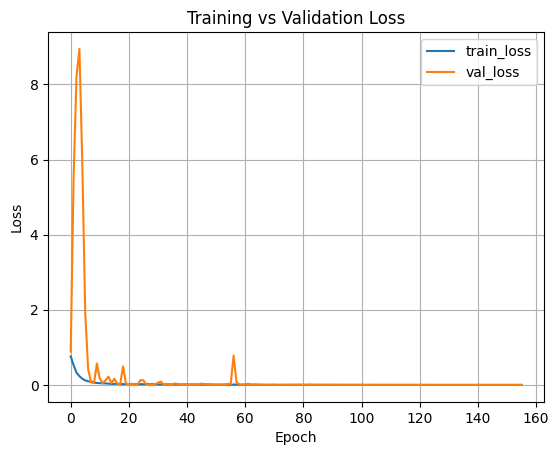

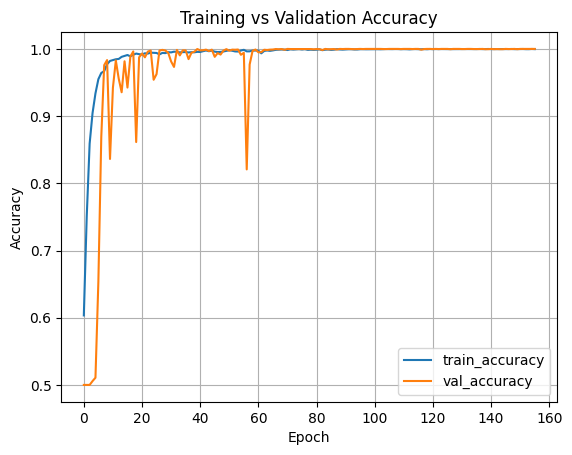


[STEP 10] Predicting test data...
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step


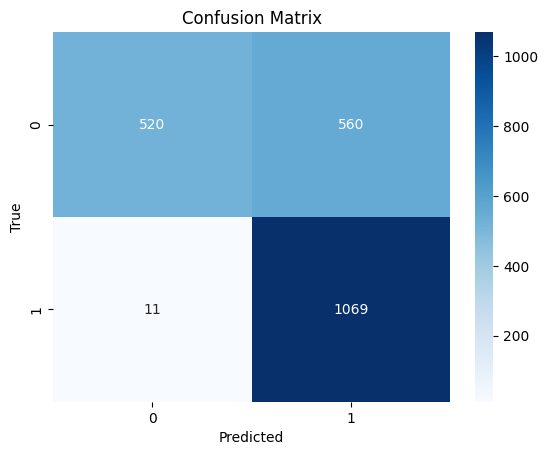

Confusion Matrix:
[[ 520  560]
 [  11 1069]]
Accuracy: 0.7356
Precision: 0.6562
Recall/Sensitivity: 0.9898
Specificity: 0.4815
F1-Score: 0.7892
Cohen's Kappa: 0.4713
[STEP 10] Model saved as eegformer-final.h5


In [13]:
# ============================================================
# GPU / TensorFlow clean initialization cell
# Run this BEFORE building the model
# ============================================================

import os  # Import OS
import gc  # Import garbage collector
import numpy as np  # Import NumPy
import tensorflow as tf  # Import TensorFlow
from tensorflow.keras import backend as K  # Import Keras backend

print("[ENV] TensorFlow version:", tf.__version__)  # Print TensorFlow version
print("[ENV] Physical GPUs:", tf.config.list_physical_devices("GPU"))  # Print GPU list

K.clear_session()  # Clear old TensorFlow graph/session
gc.collect()  # Run garbage collection

gpus = tf.config.list_physical_devices("GPU")  # Get physical GPUs

if gpus:  # Check if GPU exists
    try:  # Try setting memory growth
        for gpu in gpus:  # Loop through GPUs
            tf.config.experimental.set_memory_growth(gpu, True)  # Enable memory growth
        print("[ENV] GPU memory growth enabled.")  # Print success
    except RuntimeError as e:  # Catch memory growth error
        print("[ENV] Could not set memory growth:", e)  # Print error

try:  # Try small GPU test
    with tf.device("/GPU:0"):  # Use GPU
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]], dtype=tf.float32)  # Create tensor
        b = tf.cast(a, tf.float32)  # Cast tensor
        c = tf.matmul(b, b)  # Matrix multiply
    print("[ENV] GPU TensorFlow test passed:")  # Print success
    print(c)  # Print result
except Exception as e:  # Catch GPU test error
    print("[ENV] GPU TensorFlow test failed.")  # Print fail
    print(type(e).__name__, ":", e)  # Print error


from tensorflow.keras.losses import BinaryCrossentropy  # Import binary loss
from tensorflow.keras.metrics import BinaryAccuracy  # Import binary accuracy

# %% Step 10 - Modeling, training, and evaluation using EEGFormer

print("\n[STEP 10] Splitting train/validation data...")  # Print split start

X_train, X_val, y_train, y_val = train_test_split(
    train_data_norm,
    selected_targets,
    test_size=0.2,
    random_state=42,
    stratify=selected_targets
)  # Split train data into train and validation

print(f"[STEP 10] Training data shape: {X_train.shape}")  # Print train shape
print(f"[STEP 10] Validation data shape: {X_val.shape}")  # Print validation shape
print(f"[STEP 10] y_train shape: {y_train.shape}")  # Print y_train shape
print(f"[STEP 10] y_val shape: {y_val.shape}")  # Print y_val shape


def get_lr(opt):  # Define helper to get learning rate
    try:
        return float(tf.keras.backend.get_value(opt.learning_rate))
    except Exception:
        try:
            return float(opt.learning_rate.numpy())
        except Exception:
            try:
                return float(opt.lr.numpy())
            except Exception:
                return float(getattr(opt, "lr", 0.0))


def _cap_kernel(k: int, S: int) -> int:  # Define safe kernel size helper
    return max(1, min(int(k), int(S)))  # Cap kernel size to signal length


def _pick_safe_temporal_pools(S: int, preferred=(8, 4)):  # Define safe pooling helper
    candidates = [
        preferred,
        (4, 4),
        (4, 3),
        (3, 3),
        (3, 2),
        (2, 2),
        (2, 1),
        (1, 1)
    ]  # Candidate pooling values

    for p1, p2 in candidates:  # Loop candidates
        if (S // p1) // p2 >= 1:  # Check valid pooled length
            return (1, p1), (1, p2)  # Return valid pools

    return (1, 1), (1, 1)  # Fallback pools


def SpatialAttention(x):  # Define spatial attention block
    attn = GlobalAveragePooling2D()(x)  # Global average pooling
    attn = Dense(64, activation="relu")(attn)  # Dense layer

    M = K.int_shape(x)[1]  # Get electrode dimension

    if M is None:  # Check electrode dimension
        raise ValueError("Electrode dimension must be known")  # Raise error

    attn = Dense(M, activation="sigmoid")(attn)  # Create attention weights
    attn = Reshape((M, 1, 1))(attn)  # Reshape attention weights

    return Multiply()([x, attn])  # Apply attention


def TransformerBlock(
    x,
    num_heads=4,
    key_dim=32,
    ff_dim=128,
    dropout_rate=0.1
):  # Define transformer block
    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim
    )(x, x)  # Multi-head self-attention

    attn = Dropout(dropout_rate)(attn)  # Apply dropout

    x = Add()([x, attn])  # Add residual connection
    x = LayerNormalization()(x)  # Normalize

    ff = Dense(ff_dim, activation="relu")(x)  # Feed-forward layer
    ff = Dropout(dropout_rate)(ff)  # Dropout
    ff = Dense(K.int_shape(x)[-1])(ff)  # Project back

    x = Add()([x, ff])  # Add residual connection
    x = LayerNormalization()(x)  # Normalize

    return x  # Return transformer output


def EEGNet_SpatialTransformer(
    input_shape,
    dropout_rate=0.5,
    num_heads=4,
    ff_dim=128
):  # Define EEGFormer model
    M, S, C = input_shape  # Unpack input shape

    if C != 1:  # Check channel dimension
        raise ValueError("Expected input_shape=(M, S, 1)")  # Raise error

    k1 = _cap_kernel(5, S)  # Safe first kernel
    k2 = _cap_kernel(3, S)  # Safe second kernel

    pool1, pool2 = _pick_safe_temporal_pools(S)  # Select safe pooling

    inputs = Input(shape=input_shape)  # Input layer

    x = SeparableConv2D(
        32,
        (1, k1),
        padding="same",
        use_bias=False
    )(inputs)  # Temporal separable convolution

    x = BatchNormalization()(x)  # Batch normalization
    x = Activation("relu")(x)  # ReLU activation

    x = SpatialAttention(x)  # Spatial attention

    x = DepthwiseConv2D(
        (M, 1),
        depth_multiplier=2,
        padding="same",
        use_bias=False
    )(x)  # Depthwise spatial convolution

    x = BatchNormalization()(x)  # Batch normalization
    x = Activation("relu")(x)  # ReLU activation

    ch_out = K.int_shape(x)[-1]  # Get output channels

    proj = Conv2D(
        ch_out,
        (1, 1),
        padding="same",
        use_bias=False
    )(inputs)  # Projection branch

    proj = BatchNormalization()(proj)  # Normalize projection

    x = Add()([x, proj])  # Add residual projection
    x = BatchNormalization()(x)  # Batch normalization

    x = AveragePooling2D(pool1)(x)  # Average pooling
    x = Dropout(dropout_rate)(x)  # Dropout

    x = SeparableConv2D(
        64,
        (1, k2),
        padding="same",
        use_bias=False
    )(x)  # Second separable convolution

    x = BatchNormalization()(x)  # Batch normalization
    x = Activation("relu")(x)  # ReLU activation

    x = AveragePooling2D(pool2)(x)  # Average pooling
    x = Dropout(dropout_rate)(x)  # Dropout

    _, M_eff, S_eff, C_eff = K.int_shape(x)  # Get effective dimensions

    x = Reshape((M_eff, S_eff * C_eff))(x)  # Reshape for transformer

    x = TransformerBlock(
        x,
        num_heads=num_heads,
        ff_dim=ff_dim
    )  # Apply transformer block

    x = GlobalAveragePooling1D()(x)  # Global average pooling
    x = BatchNormalization()(x)  # Batch normalization

    x = Dense(128, activation="relu")(x)  # Dense layer
    x = BatchNormalization()(x)  # Batch normalization
    x = Dropout(dropout_rate)(x)  # Dropout

    outputs = Dense(1, activation="sigmoid")(x)  # Binary classification output

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="EEGNet_SpatialTransformer_refit"
    )  # Create model

    return model  # Return model


print("\n[STEP 10] Checking required variables...")  # Print check start

for name in ["X_train", "X_val", "y_train", "y_val", "test_data_norm", "y_test_cnn"]:  # Loop required variables
    assert name in globals(), f"[ERROR] Missing required variable: {name}"  # Validate variable exists

print("[STEP 10] Required variables are available.")  # Print success

n_electrodes = X_train.shape[1]  # Get number of electrodes
segment_size = X_train.shape[2]  # Get segment size
input_shape = (n_electrodes, segment_size, 1)  # Create input shape

print(f"[STEP 10] Model input shape: {input_shape}")  # Print input shape

X_train = X_train.astype(np.float32, copy=False)  # Convert train data to float32
X_val = X_val.astype(np.float32, copy=False)  # Convert validation data to float32

y_train = y_train.astype(np.float32, copy=False)  # Convert train labels to float32
y_val = y_val.astype(np.float32, copy=False)  # Convert validation labels to float32

print("[STEP 10] Unique training labels:", np.unique(y_train))  # Print labels

print("\n[STEP 10] Building EEGFormer model...")  # Print model build start

model = EEGNet_SpatialTransformer(
    input_shape=input_shape,
    dropout_rate=0.5,
    num_heads=4,
    ff_dim=128
)  # Build model

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=BinaryCrossentropy(),
    metrics=[BinaryAccuracy(name="accuracy", threshold=0.5)]
)  # Compile model

model.summary()  # Print model summary

print("[STEP 10] Initial LR:", get_lr(model.optimizer))  # Print initial learning rate


lr_scheduler = ReduceLROnPlateau(
    monitor="loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)  # Define LR scheduler

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=50,
    restore_best_weights=True,
    verbose=1
)  # Define early stopping

ckpt = ModelCheckpoint(
    filepath="sub-69_eegformer_model.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)  # Define model checkpoint

csv_logger = CSVLogger(
    "eegformer_training_log.csv",
    append=False
)  # Define CSV logger

callbacks = [lr_scheduler, early_stop, ckpt, csv_logger]  # Create callback list

EPOCHS = 300  # Set number of epochs
BATCH_SIZE = 200  # Set batch size

print("\n[STEP 10] Starting EEGFormer training...")  # Print training start

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)  # Train model

print("[STEP 10] Training complete.")  # Print training completion
print("[STEP 10] Best val_loss    :", float(np.min(history.history["val_loss"])))  # Print best val loss
print("[STEP 10] Best val_accuracy:", float(np.max(history.history["val_accuracy"])))  # Print best val accuracy
print("[STEP 10] Final LR         :", get_lr(model.optimizer))  # Print final LR


print("\n[STEP 10] Evaluating on held-out test set...")  # Print evaluation start

X_test_final = test_data_norm.astype(np.float32, copy=False)  # Convert test data to float32
y_test_final = y_test_cnn.astype(np.float32, copy=False)  # Convert test labels to float32

test_loss, test_acc = model.evaluate(
    X_test_final,
    y_test_final,
    batch_size=BATCH_SIZE,
    verbose=1
)  # Evaluate model

print(f"[STEP 10] Test loss    : {test_loss:.4f}")  # Print test loss
print(f"[STEP 10] Test accuracy: {test_acc:.4f}")  # Print test accuracy


plt.figure()  # Create figure
plt.plot(history.history["loss"], label="train_loss")  # Plot training loss
plt.plot(history.history["val_loss"], label="val_loss")  # Plot validation loss
plt.xlabel("Epoch")  # X label
plt.ylabel("Loss")  # Y label
plt.title("Training vs Validation Loss")  # Plot title
plt.legend()  # Show legend
plt.grid(True)  # Show grid
plt.show()  # Show plot


plt.figure()  # Create figure
plt.plot(history.history["accuracy"], label="train_accuracy")  # Plot train accuracy
plt.plot(history.history["val_accuracy"], label="val_accuracy")  # Plot validation accuracy
plt.xlabel("Epoch")  # X label
plt.ylabel("Accuracy")  # Y label
plt.title("Training vs Validation Accuracy")  # Plot title
plt.legend()  # Show legend
plt.grid(True)  # Show grid
plt.show()  # Show plot


print("\n[STEP 10] Predicting test data...")  # Print prediction start

y_pred_probs = model.predict(X_test_final, verbose=1)  # Predict test probabilities

y_pred = (y_pred_probs >= 0.5).astype(int).reshape(-1)  # Convert probabilities to binary labels

y_test_final_int = y_test_final.astype(int).reshape(-1)  # Convert test labels to int

conf_matrix = confusion_matrix(y_test_final_int, y_pred)  # Create confusion matrix

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")  # Plot confusion matrix
plt.xlabel("Predicted")  # X label
plt.ylabel("True")  # Y label
plt.title("Confusion Matrix")  # Title
plt.show()  # Show plot

print("Confusion Matrix:")  # Print label
print(conf_matrix)  # Print confusion matrix


TN, FP = conf_matrix[0, 0], conf_matrix[0, 1]  # Get TN and FP
FN, TP = conf_matrix[1, 0], conf_matrix[1, 1]  # Get FN and TP

accuracy = (TP + TN) / (TP + TN + FP + FN)  # Calculate accuracy

precision = TP / (TP + FP) if (TP + FP) != 0 else 0  # Calculate precision

recall = TP / (TP + FN) if (TP + FN) != 0 else 0  # Calculate recall

specificity = TN / (TN + FP) if (TN + FP) != 0 else 0  # Calculate specificity

f1_score = (
    2 * (precision * recall) / (precision + recall)
    if (precision + recall) != 0
    else 0
)  # Calculate F1 score

print(f"Accuracy: {accuracy:.4f}")  # Print accuracy
print(f"Precision: {precision:.4f}")  # Print precision
print(f"Recall/Sensitivity: {recall:.4f}")  # Print recall
print(f"Specificity: {specificity:.4f}")  # Print specificity
print(f"F1-Score: {f1_score:.4f}")  # Print F1 score

kappa = cohen_kappa_score(y_test_final_int, y_pred)  # Calculate Cohen's Kappa
print(f"Cohen's Kappa: {kappa:.4f}")  # Print Kappa

model.save("eegformer-final.h5")  # Save final model
print("[STEP 10] Model saved as eegformer-final.h5")  # Print save message

Step 11 — Gradient-Based Saliency

In [14]:
# %% Step 11 - Gradient-based saliency scores

print("\n[STEP 11] Starting gradient-based saliency computation...")  # Print start


def compute_electrode_saliency(model, input_sample):  # Define saliency function
    input_sample = tf.convert_to_tensor(input_sample, dtype=tf.float32)  # Convert input to TensorFlow tensor

    with tf.GradientTape() as tape:  # Start gradient tape
        tape.watch(input_sample)  # Watch input sample
        prediction = model(input_sample, training=False)  # Get prediction

    grads = tape.gradient(prediction, input_sample)  # Calculate gradients
    grads = tf.abs(grads)  # Take absolute gradients

    saliency = tf.reduce_mean(grads, axis=(2, 3))  # Average gradients over time and channel dimension

    return saliency.numpy().flatten()  # Return saliency as flat array


all_saliencies = []  # Store saliency arrays

for i in tqdm(range(train_data_norm.shape[0]), desc="Computing Saliency"):  # Loop through training samples
    sample = train_data_norm[i:i + 1]  # Select one sample
    saliency = compute_electrode_saliency(model, sample)  # Compute saliency
    all_saliencies.append(saliency)  # Store saliency

all_saliencies = np.array(all_saliencies, dtype=np.float32)  # Convert saliency list to array

mean_saliency = np.mean(all_saliencies, axis=0)  # Average saliency across samples

normalized_saliency = mean_saliency / np.max(mean_saliency)  # Normalize saliency

electrode_names = [
    "Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7", "FC1", "FC3", "FC5", "FT7",
    "Cz", "C1", "C3", "C5", "T7", "CP1", "CP3", "CP5", "TP7", "TP9", "Pz", "P1",
    "P3", "P5", "P7", "PO3", "PO7", "Oz", "O1", "Fpz", "Fp2", "AF4", "AF8", "F2",
    "F4", "F6", "F8", "FC2", "FC4", "FC6", "FT8", "C2", "C4", "C6", "T8", "CPz",
    "CP2", "CP4", "CP6", "TP8", "TP10", "P2", "P4", "P6", "P8", "POz", "PO4", "PO8", "O2"
]  # Electrode names

if len(electrode_names) != len(normalized_saliency):  # Check electrode count
    raise RuntimeError(
        f"[STEP 11] Electrode name count {len(electrode_names)} does not match "
        f"saliency length {len(normalized_saliency)}."
    )  # Raise mismatch error

saliency_df = pd.DataFrame({
    "Electrode": electrode_names,
    "Saliency Score": normalized_saliency
})  # Create saliency dataframe

saliency_df.to_csv("sub69_gradient_saliency_scores.csv", index=False)  # Save saliency CSV

print("[STEP 11] Saved gradient saliency scores to sub71_gradient_saliency_scores.csv")  # Print save message
print(saliency_df.head())  # Print first rows


[STEP 11] Starting gradient-based saliency computation...


Computing Saliency:   0%|          | 0/28000 [00:00<?, ?it/s]

[STEP 11] Saved gradient saliency scores to sub71_gradient_saliency_scores.csv
  Electrode  Saliency Score
0       Fp1        0.535667
1       AF3        0.162218
2       AF7        0.731309
3        Fz        0.486900
4        F1        0.136613


Step 12 — Brain Topographic Map


[STEP 12] Creating topographic map of electrode importance...


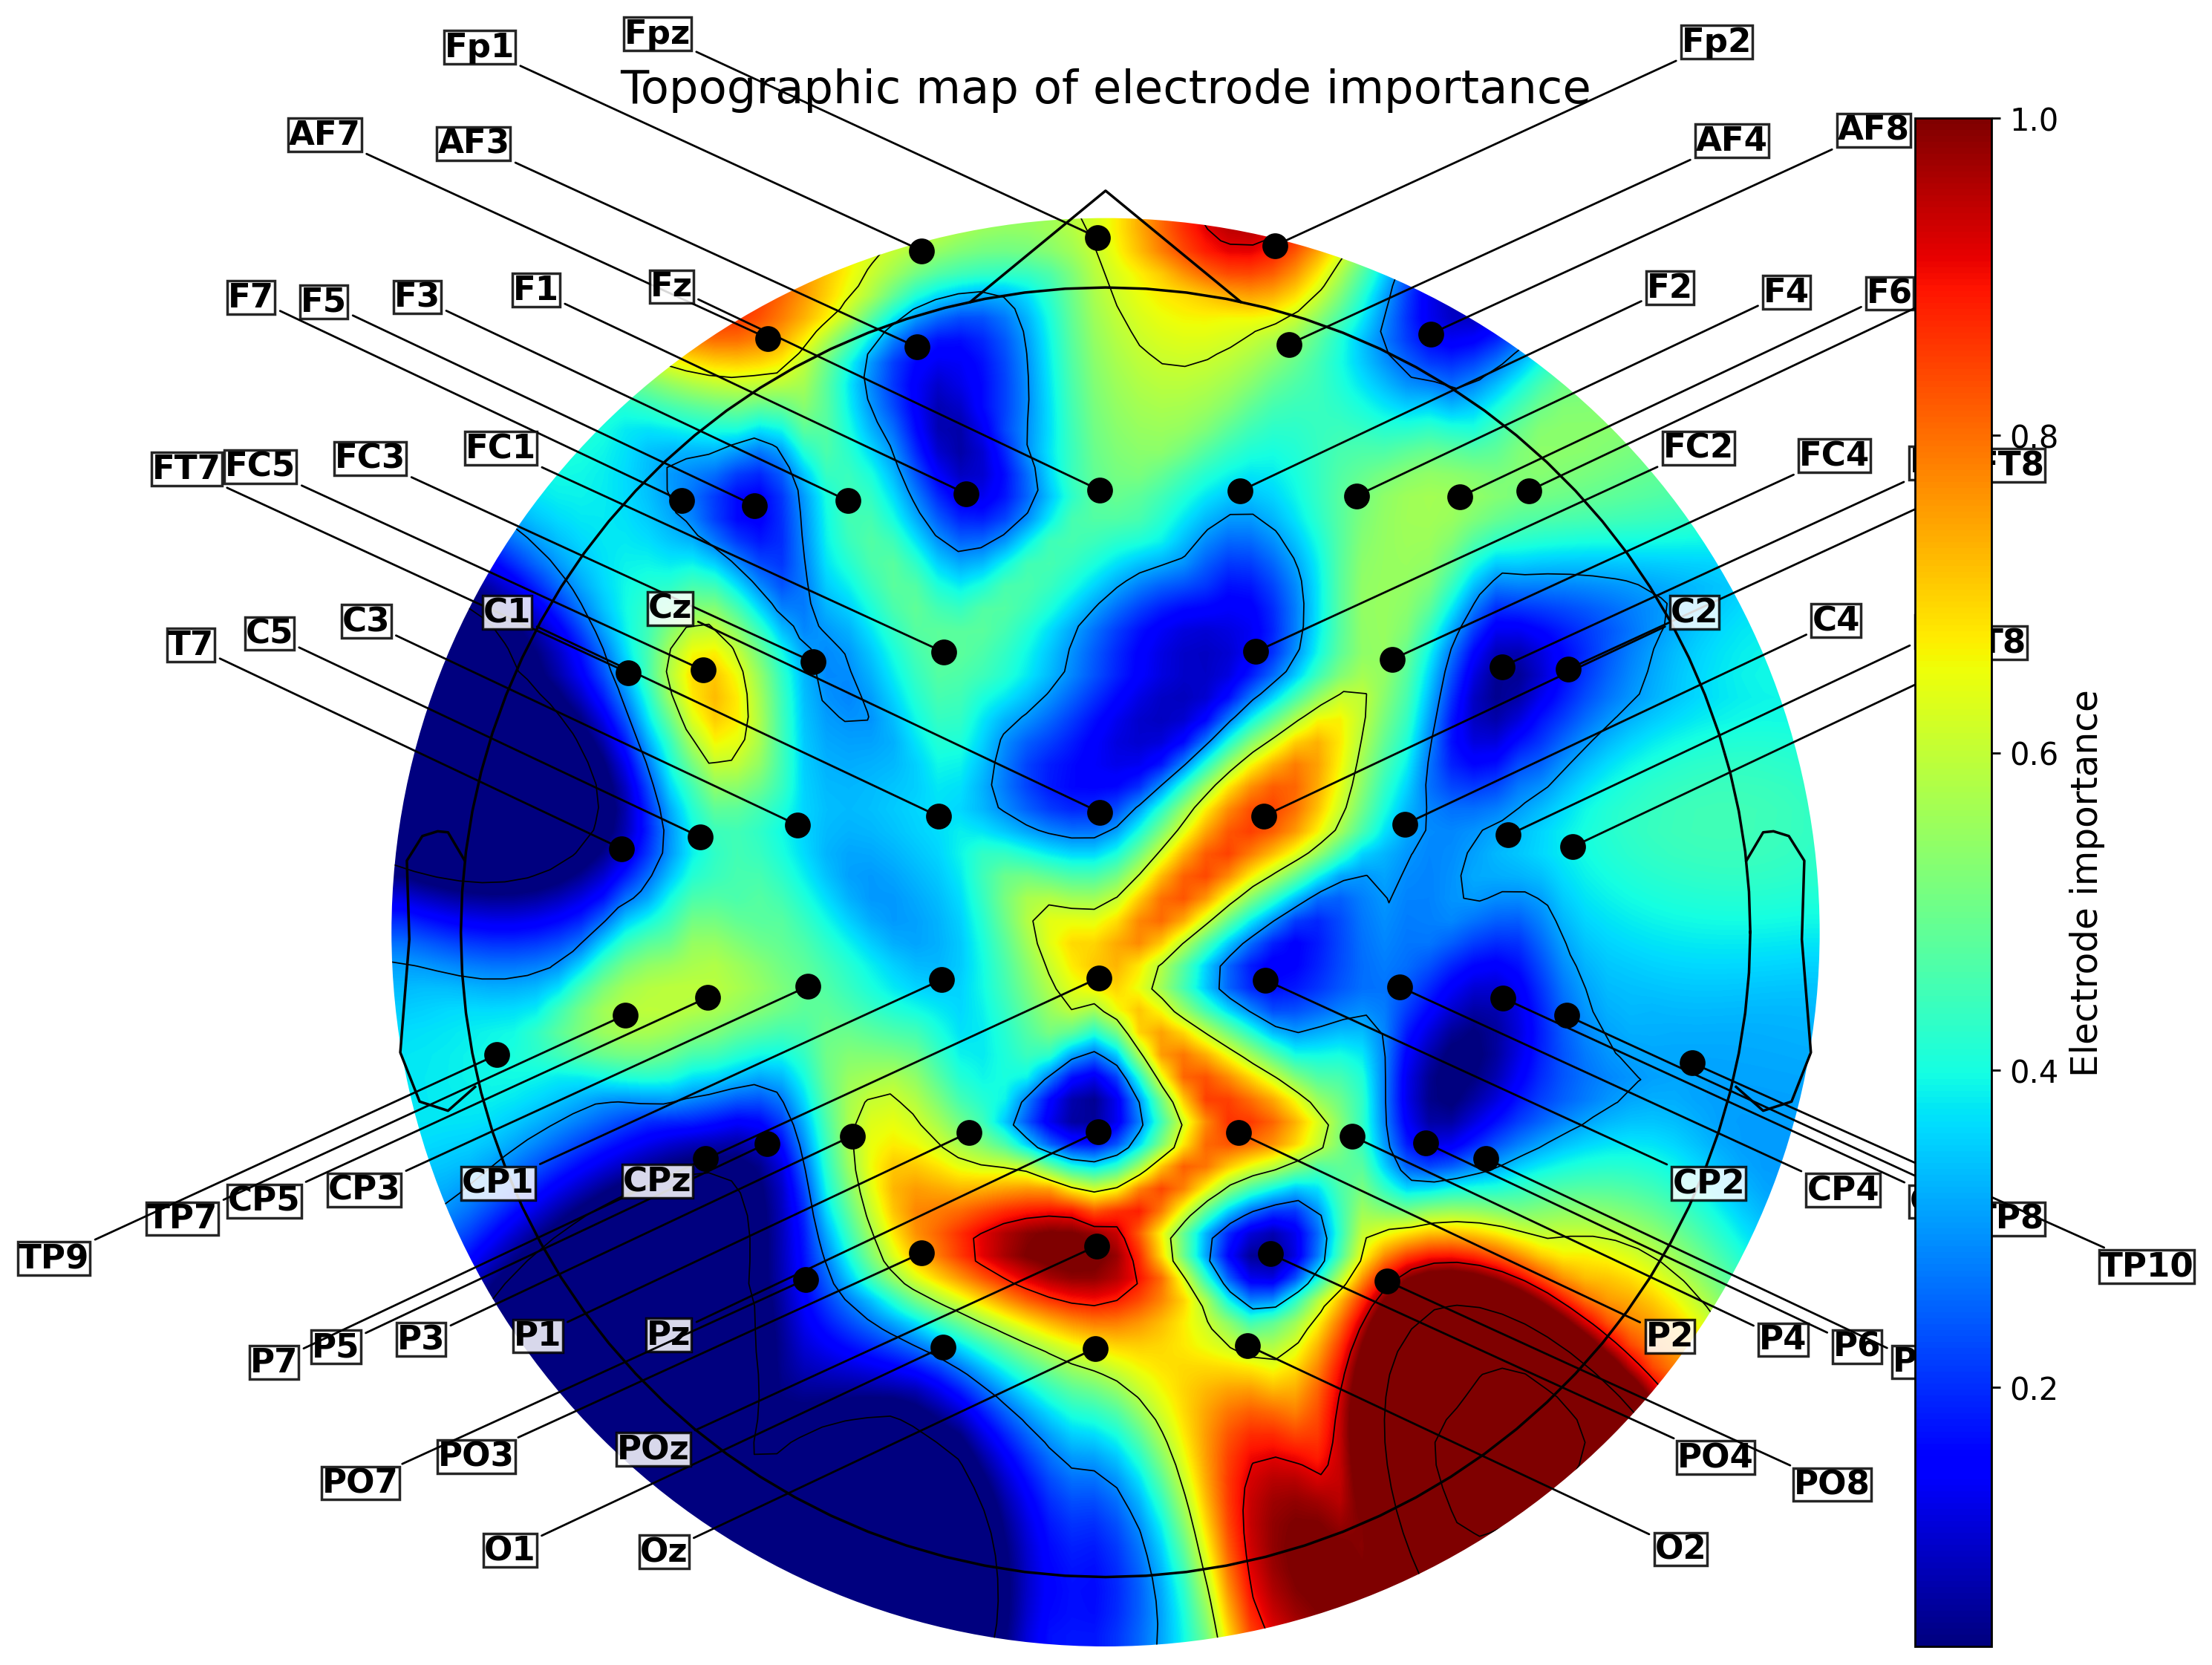

[STEP 12] Topographic map completed.


In [15]:
# %% Step 12 - Brain topographic map

print("\n[STEP 12] Creating topographic map of electrode importance...")  # Print start

if "normalized_saliency" in globals() and "electrode_names" in globals():  # Check if saliency exists
    ch_names = list(electrode_names)  # Use electrode names
    values = np.asarray(normalized_saliency, dtype=float)  # Use saliency values
else:  # If saliency variables do not exist
    df = pd.read_csv("sub71_gradient_saliency_scores.csv")  # Read saliency CSV
    ch_names = df["Electrode"].astype(str).tolist()  # Get electrode names
    values = df["Saliency Score"].to_numpy(dtype=float)  # Get saliency scores

info = mne.create_info(
    ch_names=ch_names,
    sfreq=500.0,
    ch_types="eeg"
)  # Create MNE info

montage = mne.channels.make_standard_montage("standard_1020")  # Create standard_1020 montage

info.set_montage(
    montage,
    match_case=False,
    on_missing="ignore"
)  # Attach montage

good_idx = []  # Store electrodes with valid coordinates

for i, ch in enumerate(info["chs"]):  # Loop channels
    xyz = ch["loc"][:3]  # Get 3D location

    if np.any(xyz) and np.all(np.isfinite(xyz)):  # Check valid coordinate
        good_idx.append(i)  # Store good index

values_good = values[good_idx]  # Select valid values

info_good = mne.pick_info(info, sel=good_idx)  # Select valid channel info

names_good = info_good.ch_names  # Get valid channel names

coords2d = mne.channels.layout._find_topomap_coords(
    info_good,
    picks=np.arange(len(names_good))
)  # Get 2D coordinates

fig, ax = plt.subplots(figsize=(14, 9), dpi=250)  # Create figure

vmin, vmax = float(values_good.min()), float(values_good.max())  # Get color limits

im, cn = mne.viz.plot_topomap(
    values_good,
    info_good,
    axes=ax,
    show=False,
    contours=6,
    sensors=False,
    outlines="head",
    vlim=(vmin, vmax),
    cmap="jet"
)  # Plot topomap

dot_size = 18  # Dot size
font_size = 13  # Font size
arrow_lw = 0.8  # Arrow line width

for (x, y), name in zip(coords2d, names_good):  # Loop coordinates and names
    ax.plot(x, y, "k.", markersize=dot_size, zorder=10)  # Plot electrode dot

    x_off = 0.06 if x >= 0 else -0.06  # Set x offset
    y_off = 0.03 if y >= 0 else -0.03  # Set y offset

    ax.annotate(
        name,
        xy=(x, y),
        xytext=(x + x_off, y + y_off),
        textcoords="data",
        fontsize=font_size,
        fontweight="bold",
        ha="left" if x >= 0 else "right",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.85,
            pad=0.2
        ),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=arrow_lw
        ),
        zorder=11
    )  # Add electrode label

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Add colorbar
cbar.set_label("Electrode importance", fontsize=14)  # Set colorbar label
cbar.ax.tick_params(labelsize=12)  # Set colorbar tick size

ax.set_title(
    "Topographic map of electrode importance",
    fontsize=18
)  # Set plot title

ax.set_axis_off()  # Hide axis

plt.tight_layout()  # Adjust layout
plt.show()  # Show topomap

print("[STEP 12] Topographic map completed.")  # Print completion

Step 13 — Attention-Based Saliency Score

In [16]:
# %% Step 13 - Attention-based saliency score

import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm.auto import tqdm

print("\n[STEP 13] Starting attention-based saliency computation...")


# ============================================================
# 1. Find the spatial-attention Dense layer
# ============================================================

def find_spatial_attention_layer(model, expected_electrodes):
    """
    Find the Dense sigmoid layer that produces one attention
    value for each EEG electrode.
    """

    print(
        f"[STEP 13] Searching for attention layer with "
        f"{expected_electrodes} outputs..."
    )

    matching_layers = []

    for layer in model.layers:

        # Only inspect Dense layers
        if isinstance(layer, tf.keras.layers.Dense):

            # Get number of output units
            units = getattr(layer, "units", None)

            # Get activation function name
            activation_name = getattr(
                getattr(layer, "activation", None),
                "__name__",
                ""
            )

            print(
                f"[STEP 13] Dense layer: {layer.name}, "
                f"units={units}, activation={activation_name}"
            )

            # Spatial attention layer should:
            # 1. Have one output per electrode
            # 2. Use sigmoid activation
            if (
                units == expected_electrodes
                and activation_name == "sigmoid"
            ):
                matching_layers.append(layer)

    if len(matching_layers) == 0:
        raise ValueError(
            "[STEP 13] Could not find a Dense sigmoid layer "
            f"with {expected_electrodes} outputs."
        )

    # Normally there should be only one matching layer
    attention_layer = matching_layers[0]

    print(
        f"[STEP 13] Attention layer found: "
        f"{attention_layer.name}"
    )

    return attention_layer


# Number of electrodes in model input
expected_electrodes = int(train_data_norm.shape[1])

# Locate spatial attention layer
attention_layer = find_spatial_attention_layer(
    model=model,
    expected_electrodes=expected_electrodes
)


# ============================================================
# 2. Create attention-output model
# ============================================================

attention_model = tf.keras.Model(
    inputs=model.input,
    outputs=attention_layer.output
)

print("[STEP 13] Attention extraction model created.")

print(
    "[STEP 13] Attention output shape:",
    attention_model.output_shape
)


# ============================================================
# 3. Compute attention scores in batches
# ============================================================

ATTENTION_BATCH_SIZE = 256

all_attention_scores = []

number_of_samples = train_data_norm.shape[0]

number_of_batches = int(
    np.ceil(number_of_samples / ATTENTION_BATCH_SIZE)
)

print(
    f"[STEP 13] Total samples: {number_of_samples}"
)

print(
    f"[STEP 13] Batch size: {ATTENTION_BATCH_SIZE}"
)

print(
    f"[STEP 13] Total batches: {number_of_batches}"
)


for start_index in tqdm(
    range(0, number_of_samples, ATTENTION_BATCH_SIZE),
    desc="Computing Attention Saliency",
    unit="batch"
):

    end_index = min(
        start_index + ATTENTION_BATCH_SIZE,
        number_of_samples
    )

    # Select one batch
    batch = train_data_norm[
        start_index:end_index
    ].astype(
        np.float32,
        copy=False
    )

    # Extract attention scores
    batch_attention = attention_model(
        batch,
        training=False
    ).numpy()

    # Expected shape:
    # (batch_size, number_of_electrodes)
    batch_attention = batch_attention.reshape(
        batch_attention.shape[0],
        -1
    )

    all_attention_scores.append(
        batch_attention.astype(
            np.float32,
            copy=False
        )
    )


# Combine all batches
all_attention_scores = np.concatenate(
    all_attention_scores,
    axis=0
)

print(
    "[STEP 13] All attention scores shape:",
    all_attention_scores.shape
)


# ============================================================
# 4. Calculate mean attention per electrode
# ============================================================

mean_attention = np.mean(
    all_attention_scores,
    axis=0
)

print(
    "[STEP 13] Mean attention shape:",
    mean_attention.shape
)


# Normalize between 0 and 1
attention_max = np.max(mean_attention)

if attention_max > 0:

    normalized_attention = (
        mean_attention / attention_max
    )

else:

    normalized_attention = mean_attention


# ============================================================
# 5. Electrode names
# ============================================================

electrode_names = [
    "Fp1", "AF3", "AF7", "Fz", "F1", "F3",
    "F5", "F7", "FC1", "FC3", "FC5", "FT7",
    "Cz", "C1", "C3", "C5", "T7", "CP1",
    "CP3", "CP5", "TP7", "TP9", "Pz", "P1",
    "P3", "P5", "P7", "PO3", "PO7", "Oz",
    "O1", "Fpz", "Fp2", "AF4", "AF8", "F2",
    "F4", "F6", "F8", "FC2", "FC4", "FC6",
    "FT8", "C2", "C4", "C6", "T8", "CPz",
    "CP2", "CP4", "CP6", "TP8", "TP10", "P2",
    "P4", "P6", "P8", "POz", "PO4", "PO8",
    "O2"
]


# Confirm electrode count
if len(electrode_names) != len(normalized_attention):

    raise RuntimeError(
        f"[STEP 13] Electrode name count "
        f"{len(electrode_names)} does not match "
        f"attention score length "
        f"{len(normalized_attention)}."
    )


# ============================================================
# 6. Save attention scores
# ============================================================

df_attention = pd.DataFrame(
    {
        "Electrode": electrode_names,
        "Saliency Score": normalized_attention
    }
)

df_attention = df_attention.sort_values(
    by="Saliency Score",
    ascending=False
).reset_index(
    drop=True
)

df_attention.to_csv(
    "sub69_attention_saliency_scores.csv",
    index=False
)

print(
    "[STEP 13] Saved attention saliency scores to "
    "sub71_attention_saliency_scores.csv"
)

print("\n[STEP 13] Top 10 important electrodes:")

print(
    df_attention.head(10)
)

print("\n[STEP 13] Attention saliency completed successfully.")


[STEP 13] Starting attention-based saliency computation...
[STEP 13] Searching for attention layer with 61 outputs...
[STEP 13] Dense layer: dense, units=64, activation=relu
[STEP 13] Dense layer: dense_1, units=61, activation=sigmoid
[STEP 13] Dense layer: dense_2, units=128, activation=relu
[STEP 13] Dense layer: dense_3, units=192, activation=linear
[STEP 13] Dense layer: dense_4, units=128, activation=relu
[STEP 13] Dense layer: dense_5, units=1, activation=sigmoid
[STEP 13] Attention layer found: dense_1
[STEP 13] Attention extraction model created.
[STEP 13] Attention output shape: (None, 61)
[STEP 13] Total samples: 28000
[STEP 13] Batch size: 256
[STEP 13] Total batches: 110


Computing Attention Saliency:   0%|          | 0/110 [00:00<?, ?batch/s]

[STEP 13] All attention scores shape: (28000, 61)
[STEP 13] Mean attention shape: (61,)
[STEP 13] Saved attention saliency scores to sub71_attention_saliency_scores.csv

[STEP 13] Top 10 important electrodes:
  Electrode  Saliency Score
0       AF7        1.000000
1       POz        0.992869
2        P2        0.904970
3       PO8        0.892410
4       Fp1        0.861934
5        C2        0.809802
6       PO3        0.786853
7       Fp2        0.746879
8        P4        0.720092
9       FC1        0.684812

[STEP 13] Attention saliency completed successfully.
